# Figuras 6 e 7 — Envio e recebimento de texto via HTTP

Reproduz, a partir dos dados coletados nesta replicação, os gráficos equivalentes às **Figuras 6 e 7** do artigo *Comparison of WebSocket and HTTP Protocol Performance* (Łasocha & Badurowicz, 2021):

- **Figura 6**: tempo médio de **envio** (POST) de textos de 100 caracteres para o servidor, por quantidade de cópias.
- **Figura 7**: tempo médio de **recebimento** (GET) de textos de 100 caracteres a partir do servidor, por quantidade de cópias.

**Diferença em relação ao artigo original**: o estudo original comparava múltiplos navegadores (Chrome, Firefox, Edge) em dois laptops diferentes — por isso, cada gráfico tinha 6 barras por quantidade de cópias. Aqui, os testes rodam via Node.js puro (sem navegador) em um único perfil de hardware (containers Docker na mesma máquina), então cada gráfico tem **uma única série** (uma barra por quantidade de cópias).

## Configuração e carga dos dados

Este notebook espera estar em `results/notebook/` dentro do projeto, e busca os CSVs em `results/csv/` (dois níveis acima, depois entrando em `csv/`).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# notebook está em data/notebook/ -> sobe 2 níveis (data/notebook -> results -> raiz)
# e entra em results/csv
CSV_DIR = Path.cwd().parents[1] / "results" / "csv"

SEND_FILE = CSV_DIR / "http-send-oh0.csv"
RECEIVE_FILE = CSV_DIR / "http-receive-oh0.csv"

print(f"Diretório de CSVs: {CSV_DIR.resolve()}")
print(f"Existe? {CSV_DIR.exists()}")
print(f" - {SEND_FILE.name}: {'encontrado' if SEND_FILE.exists() else 'NÃO encontrado'}")
print(f" - {RECEIVE_FILE.name}: {'encontrado' if RECEIVE_FILE.exists() else 'NÃO encontrado'}")

Diretório de CSVs: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/results/csv
Existe? True
 - http-send-oh0.csv: encontrado
 - http-receive-oh0.csv: encontrado


In [32]:
df_send = pd.read_csv(SEND_FILE)
df_receive = pd.read_csv(RECEIVE_FILE)

# Formato esperado: colunas [copies, run, time_ms]
display(df_send.head())
display(df_receive.head())

,copies,run,time_ms
0,1,1,3.153
1,1,2,1.364
2,1,3,1.225
3,1,4,1.240
4,1,5,1.505


,copies,run,time_ms
0,1,1,2.193
1,1,2,2.086
2,1,3,1.600
3,1,4,2.403
4,1,5,1.098


## Checagem de integridade dos dados

O artigo mede as cópias **1, 3, 10, 30, 100, 300, 1000, 3000**, com **10 repetições** (`run`) cada. A célula abaixo avisa se algum desses pontos estiver faltando ou com menos repetições do que o esperado — isso já pegou um bug real nesta replicação antes (arquivos sobrescritos com apenas `copies=100`).

In [ ]:
EXPECTED_COPIES = [1, 3, 10, 30, 100, 300, 1000, 3000]
EXPECTED_RUNS = 10

def check_integrity(df, label):
    print(f"--- {label} ---")
    counts = df.groupby("copies")["run"].count()
    missing = [c for c in EXPECTED_COPIES if c not in counts.index]
    extra = [c for c in counts.index if c not in EXPECTED_COPIES]
    if missing:
        print(f"Faltando quantidades de cópias: {missing}")
    if extra:
        print(f"Quantidades de cópias inesperadas presentes: {extra}")
    under_run = counts[counts < EXPECTED_RUNS]
    if not under_run.empty:
        print(f"Menos de {EXPECTED_RUNS} repetições para: \n{under_run}")
    if not missing and not extra and under_run.empty:
        print("Todos os pontos esperados presentes, com o número correto de repetições.")
    print()

check_integrity(df_send, "http-send-oh0.csv")
check_integrity(df_receive, "http-receive-oh0.csv")

--- http-send-oh0.csv ---
  ✅ Todos os pontos esperados presentes, com o número correto de repetições.

--- http-receive-oh0.csv ---
  ✅ Todos os pontos esperados presentes, com o número correto de repetições.



## Cálculo das médias por quantidade de cópias

Igual à metodologia do artigo (seção 4.1): cada ponto é a média das 10 repetições.

In [34]:
def summarize(df):
    g = df.groupby("copies")["time_ms"].agg(["mean", "std", "min", "max", "count"])
    g = g.reindex([c for c in EXPECTED_COPIES if c in g.index])
    return g

summary_send = summarize(df_send)
summary_receive = summarize(df_receive)

print("Envio (Figura 6):")
display(summary_send)
print("Recebimento (Figura 7):")
display(summary_receive)

Envio (Figura 6):


,mean,std,min,max,count
copies,,,,,
1,1.7285,0.801043,0.966,3.153,10
3,4.5368,1.550184,2.739,6.879,10
10,10.8441,1.337272,9.336,13.446,10
30,31.8521,4.067032,25.687,38.228,10
100,91.3757,17.274294,68.145,119.199,10
300,161.7060,39.665070,95.490,236.757,10
1000,559.3122,114.131613,471.043,839.459,10
3000,1494.3469,271.679456,1336.493,2222.603,10


Recebimento (Figura 7):


,mean,std,min,max,count
copies,,,,,
1,1.3349,0.674798,0.677,2.403,10
3,3.0672,1.226767,1.711,5.601,10
10,9.7446,1.551908,7.109,11.987,10
30,22.4698,5.399564,15.728,31.820,10
100,71.8444,8.905651,60.394,85.994,10
300,153.2832,21.189701,127.723,203.218,10
1000,430.0165,50.459839,365.026,536.165,10
3000,1279.2073,171.502715,1087.327,1557.394,10


## Figura 6 — Envio de textos via HTTP (POST)

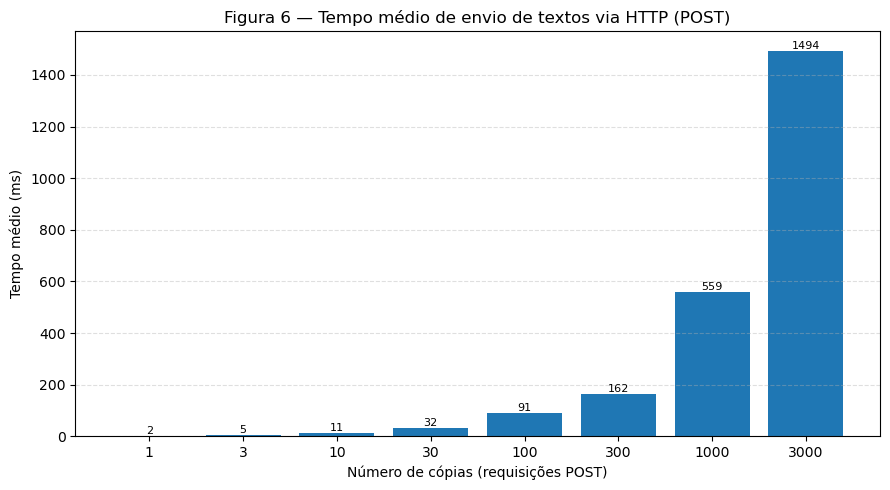

In [35]:
def plot_bar(summary, title, ylabel="Tempo médio (ms)"):
    fig, ax = plt.subplots(figsize=(9, 5))
    x_labels = [str(c) for c in summary.index]
    ax.bar(x_labels, summary["mean"], color="#1f77b4")
    ax.set_title(title)
    ax.set_xlabel("Número de cópias (requisições POST)")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for i, v in enumerate(summary["mean"]):
        ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    return fig, ax

plot_bar(
    summary_send,
    "Figura 6 — Tempo médio de envio de textos via HTTP (POST)",
)
plt.show()

## Figura 7 — Recebimento de textos via HTTP (GET)

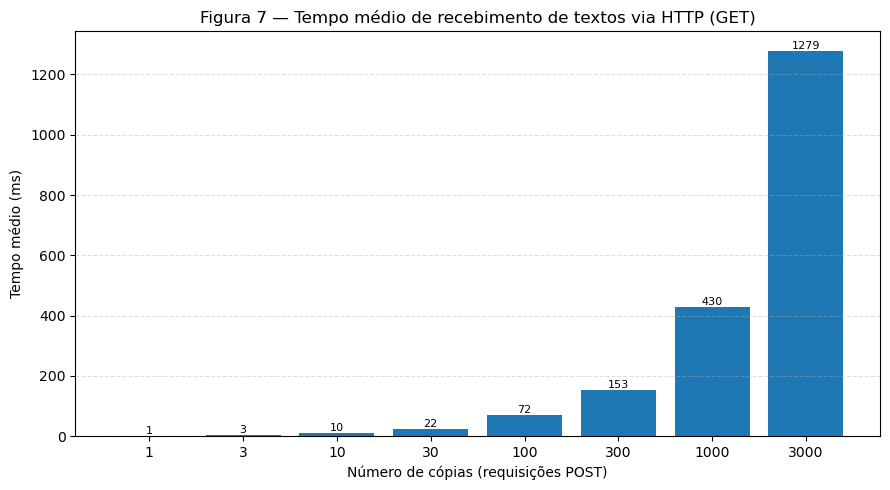

In [36]:
plot_bar(
    summary_receive,
    "Figura 7 — Tempo médio de recebimento de textos via HTTP (GET)",
    ylabel="Tempo médio (ms)",
)
plt.show()

## Exportando as figuras

Salva os dois gráficos como PNG em `results/notebook/figuras/`, prontos para o relatório.

Figuras salvas em: /home/ryan-correia/Área de trabalho/.projetos/repositorios/github/ComputerNetworksManagement/ifpb/converged_networks/advanced_project/data/plots


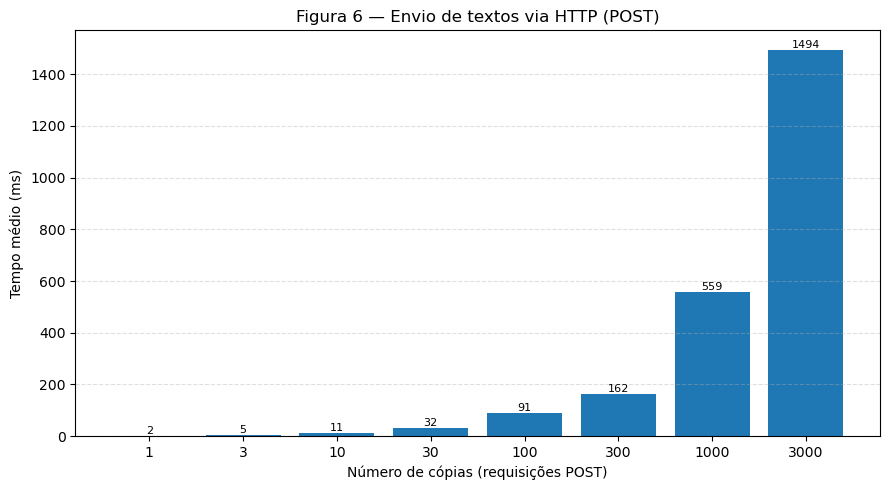

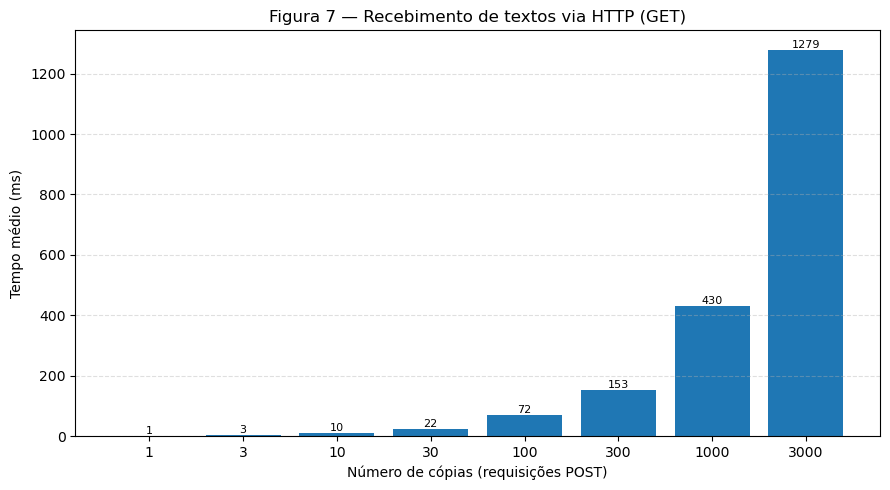

In [37]:
OUT_DIR = Path.cwd().parents[0] / "plots"
OUT_DIR.mkdir(exist_ok=True)

fig_send, _ = plot_bar(summary_send, "Figura 6 — Envio de textos via HTTP (POST)")
fig_send.savefig(OUT_DIR / "figura6_http_send.png", dpi=150)

fig_receive, _ = plot_bar(summary_receive, "Figura 7 — Recebimento de textos via HTTP (GET)")
fig_receive.savefig(OUT_DIR / "figura7_http_receive.png", dpi=150)

print(f"Figuras salvas em: {OUT_DIR.resolve()}")